In [1]:
import numpy as np
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import umap

In [16]:
# 1. 実験用データの読み込み（64次元のデータ）
digits = load_digits()
data = digits.data  # 画像データ (1797サンプル × 64特徴量)
target = digits.target  # 正解ラベル (0〜9の数字)

# 2. UMAPのモデルを作成
# 基本はデフォルト設定のままで強力に機能します
reducer = umap.UMAP(n_neighbors=2, min_dist=1, random_state=42)

# 3. 64次元のデータを2次元に変換（低次元空間への埋め込み）
embedding = reducer.fit_transform(data)

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_spectral_embedding.py:453: UserWarning: Exited at iteration 50 with accuracies 
[2.48955574e-05 5.19663825e-06 1.87311792e-04 5.93252763e-05]
not reaching the requested tolerance 5.9157609939575195e-06.
Use iteration 50 instead with accuracy 
6.918231603427837e-05.

  _, diffusion_map = lobpcg(
/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_spectral_embedding.py:453: UserWarning: Exited postprocessing with accuracies 
[2.48955571e-05 5.19663939e-06 1.87311792e-04 5.93252763e-05]
not reaching the requested tolerance 5.9157609939575195e-06.
  _, diffusion_map = lobpcg(
/

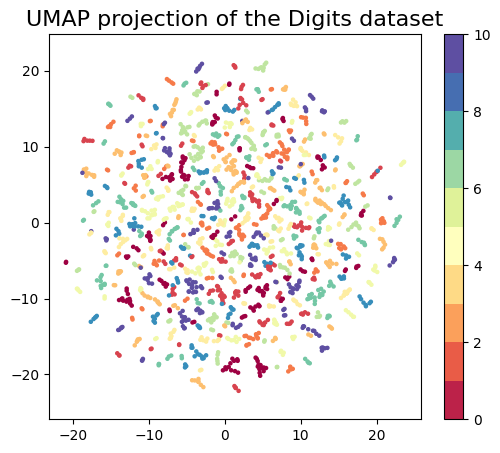

In [17]:
# 4. 2次元になったデータをグラフに描画
plt.figure(figsize=(6, 5))
# embedding[:, 0] がX軸、embedding[:, 1] がY軸になります
scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=target,
    cmap="Spectral",
    s=5,
)
plt.gca().set_aspect("equal", "datalim")
plt.colorbar(scatter, boundaries=range(11))
plt.title("UMAP projection of the Digits dataset", fontsize=16)
plt.show()

In [10]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
import umap

# 1. 既存データと新規データの準備（例として手書き数字データを使用）
digits = load_digits()
X_old = digits.data[:1500]  # 最初からあるデータ (1500サンプル)
y_old = digits.target[:1500]

X_new = digits.data[1500:]  # 新しく入ってきたデータ (297サンプル)
y_new = digits.target[1500:]

# 2. 既存データだけで UMAP を学習（fit）させる
reducer = umap.UMAP(random_state=42)
embedding_old = reducer.fit_transform(X_old)

# 3. ★新データだけを、既存の空間に変換（transform）する
# （このとき、既存のデータの位置やモデルの構造は一切変わりません）
embedding_new = reducer.transform(X_new)

/usr/local/lib/python3.10/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


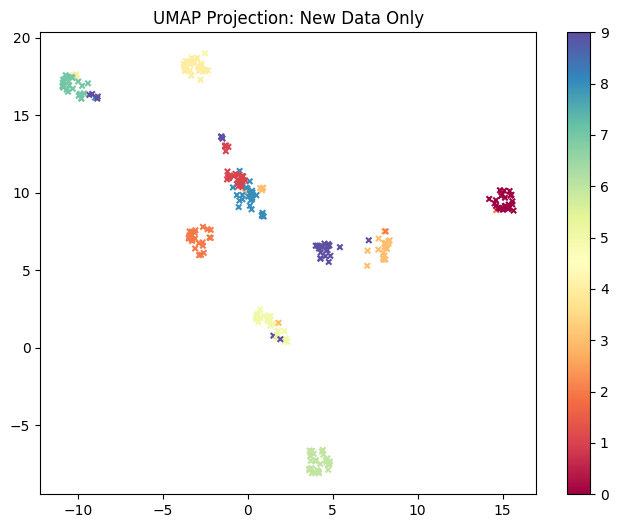

In [11]:
# 4. 新たなデータのみをプロット
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    embedding_new[:, 0],
    embedding_new[:, 1],
    c=y_new,
    cmap="Spectral",
    s=15,
    marker="x",  # 新データと分かりやすいように「×」でプロット
)
plt.colorbar(scatter)
plt.title("UMAP Projection: New Data Only")
plt.show()

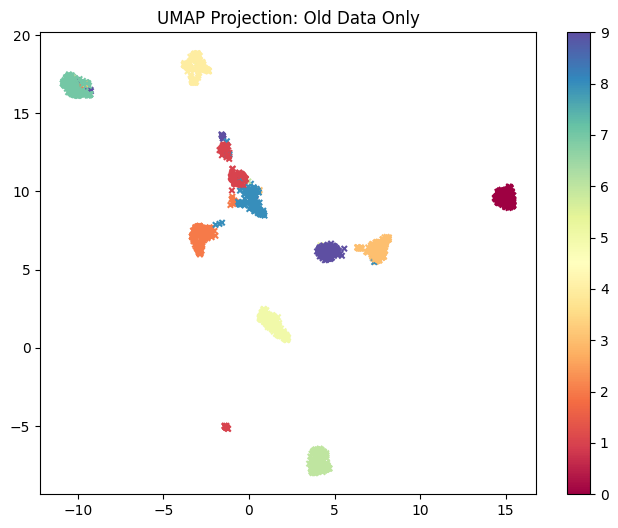

In [12]:
# 4. 新たなデータのみをプロット
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    embedding_old[:, 0],
    embedding_old[:, 1],
    c=y_old,
    cmap="Spectral",
    s=15,
    marker="x",  # 新データと分かりやすいように「×」でプロット
)
plt.colorbar(scatter)
plt.title("UMAP Projection: Old Data Only")
plt.show()